In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Paths
PROCESSED = '../data/processed/'
REPORTS = '../reports/'

# Load master dataset
df = pd.read_csv(PROCESSED + 'master_dataset.csv')

print("Data loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nBasic Stats:")
print(df.describe().round(2))

Data loaded!
Shape: (30, 10)

Columns: ['year', 'trade_value', 'avg_tariff_rate', 'unemployment_rate', 'exchange_rate_mxn', 'exchange_rate_cad', 'cpi', 'gdp_growth', 'country_Canada', 'country_Mexico']

Basic Stats:
          year  trade_value  avg_tariff_rate  unemployment_rate  \
count    30.00        30.00            30.00              30.00   
mean   2017.00       336.32             9.19               5.39   
std       4.39        67.21             0.11               1.60   
min    2010.00       229.99             9.02               3.52   
25%    2013.25       294.06             9.09               4.05   
50%    2017.00       318.58             9.18               4.67   
75%    2020.75       356.98             9.27               6.61   
max    2024.00       505.52             9.42               8.25   

       exchange_rate_mxn  exchange_rate_cad     cpi  gdp_growth  
count              30.00              30.00   30.00       30.00  
mean               16.94               1.22  254

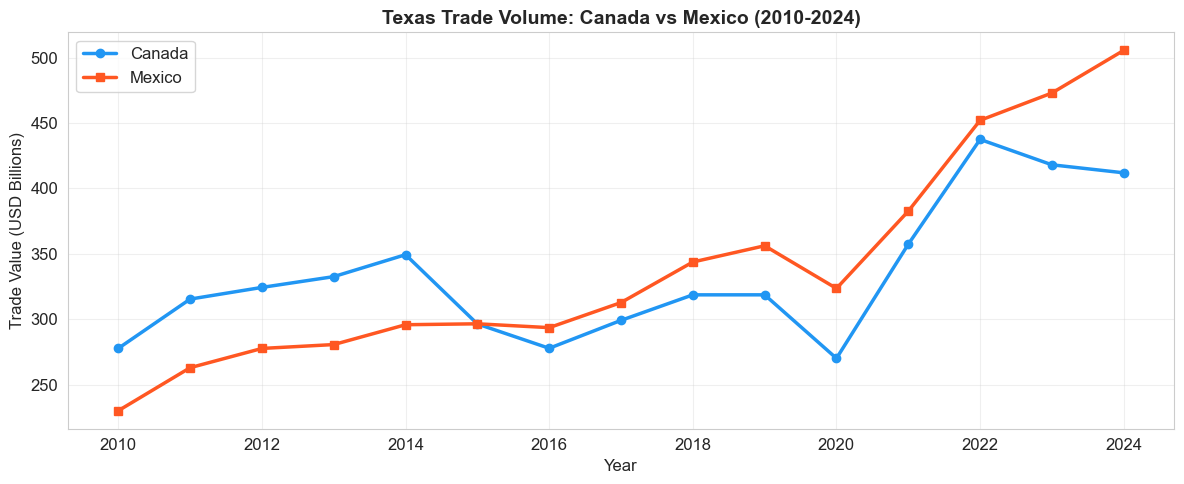

Chart 1 saved!


In [2]:
# ── Chart 1: Trade Volume Over Time ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))

canada = df[df['country_Canada'] == True].sort_values('year')
mexico = df[df['country_Mexico'] == True].sort_values('year')

ax.plot(canada['year'], canada['trade_value'], 
        marker='o', linewidth=2.5, color='#2196F3', label='Canada')
ax.plot(mexico['year'], mexico['trade_value'], 
        marker='s', linewidth=2.5, color='#FF5722', label='Mexico')

ax.set_title('Texas Trade Volume: Canada vs Mexico (2010-2024)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Trade Value (USD Billions)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS + 'chart1_trade_volume_trend.png', dpi=150)
plt.show()
print("Chart 1 saved!")

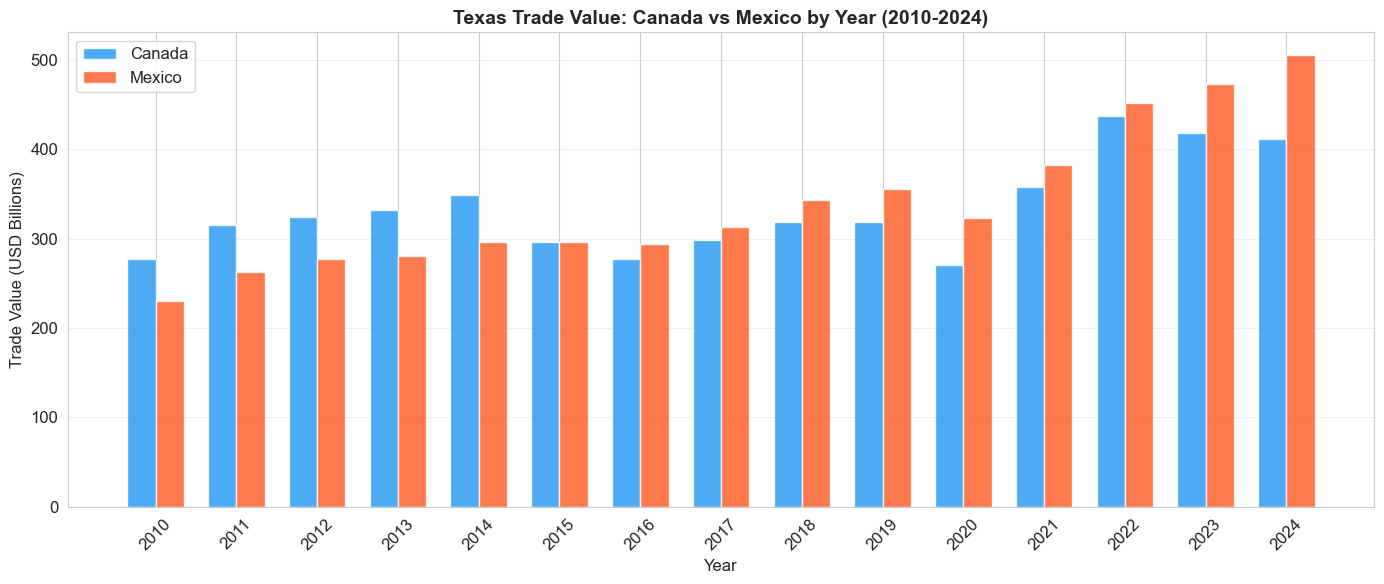

Chart 2 saved!


In [3]:
# ── Chart 2: Side by Side Bar Chart ────────────────
canada = df[df['country_Canada'] == True].sort_values('year')
mexico = df[df['country_Mexico'] == True].sort_values('year')

x = np.arange(len(canada['year']))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, canada['trade_value'], width, 
               label='Canada', color='#2196F3', alpha=0.8)
bars2 = ax.bar(x + width/2, mexico['trade_value'], width, 
               label='Mexico', color='#FF5722', alpha=0.8)

ax.set_title('Texas Trade Value: Canada vs Mexico by Year (2010-2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Trade Value (USD Billions)')
ax.set_xticks(x)
ax.set_xticklabels(canada['year'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(REPORTS + 'chart2_trade_bar.png', dpi=150)
plt.show()
print("Chart 2 saved!")

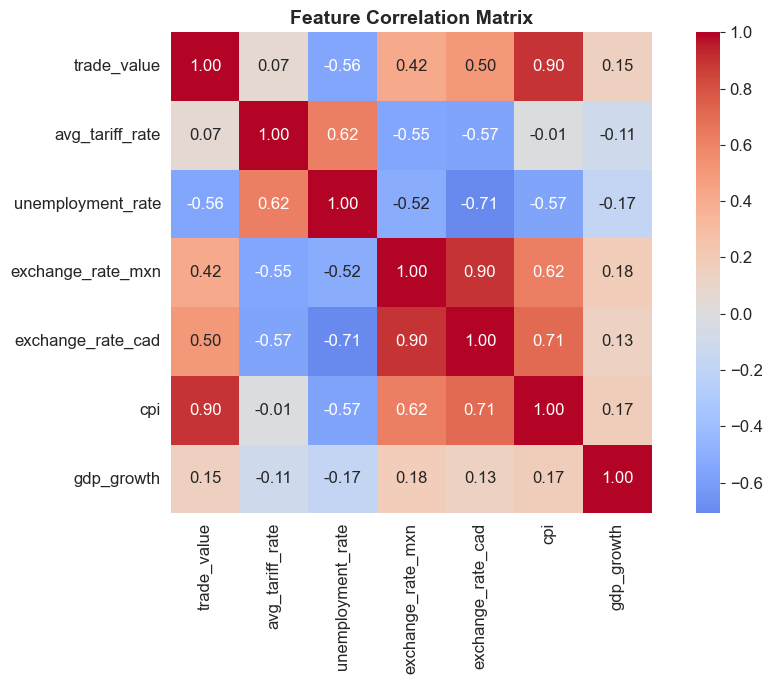

Chart 3 saved!


In [4]:
# ── Chart 3: Correlation Heatmap ───────────────────
fig, ax = plt.subplots(figsize=(10, 7))

corr_cols = ['trade_value', 'avg_tariff_rate', 'unemployment_rate',
             'exchange_rate_mxn', 'exchange_rate_cad', 'cpi', 'gdp_growth']

corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS + 'chart3_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 3 saved!")

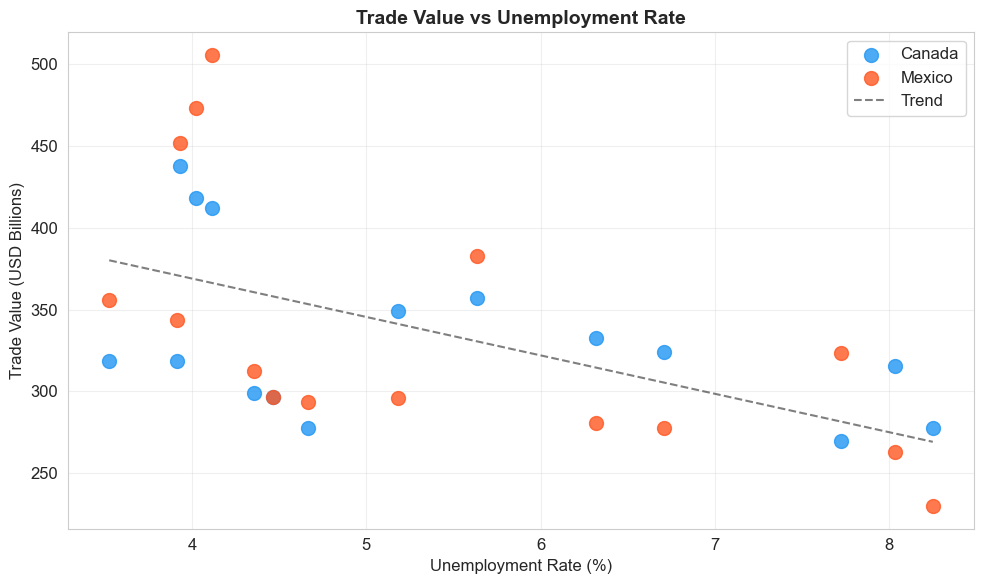

Chart 4 saved!


In [5]:
# ── Chart 4: Trade Value vs Unemployment Rate ──────
fig, ax = plt.subplots(figsize=(10, 6))

canada = df[df['country_Canada'] == True]
mexico = df[df['country_Mexico'] == True]

ax.scatter(canada['unemployment_rate'], canada['trade_value'],
           color='#2196F3', s=100, label='Canada', alpha=0.8)
ax.scatter(mexico['unemployment_rate'], mexico['trade_value'],
           color='#FF5722', s=100, label='Mexico', alpha=0.8)

# Add trend line
z = np.polyfit(df['unemployment_rate'], df['trade_value'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['unemployment_rate'].min(), df['unemployment_rate'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, label='Trend')

ax.set_title('Trade Value vs Unemployment Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Trade Value (USD Billions)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS + 'chart4_trade_vs_unemployment.png', dpi=150)
plt.show()
print("Chart 4 saved!")

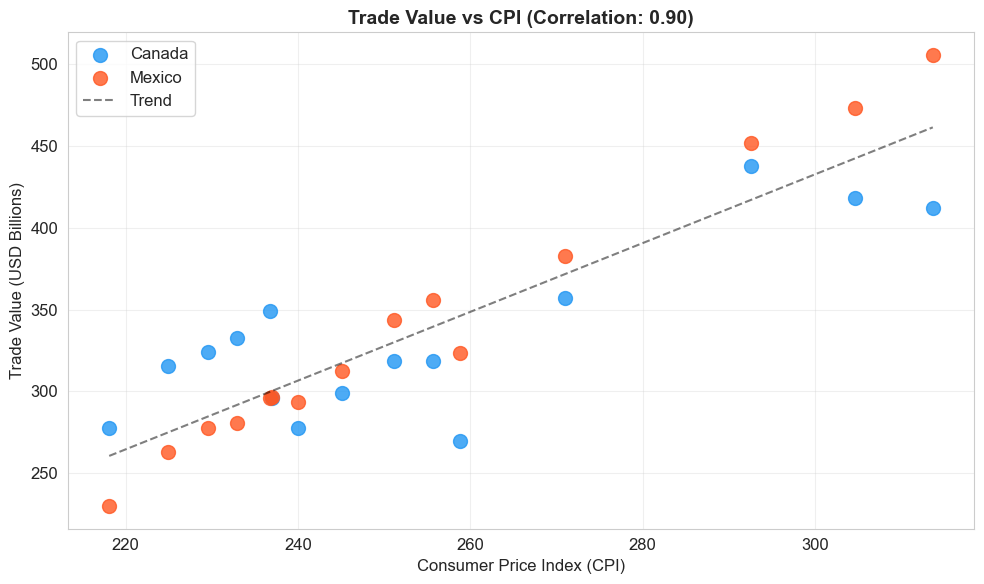

Chart 5 saved!


In [6]:
# ── Chart 5: Trade Value vs CPI ────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

canada = df[df['country_Canada'] == True]
mexico = df[df['country_Mexico'] == True]

ax.scatter(canada['cpi'], canada['trade_value'],
           color='#2196F3', s=100, label='Canada', alpha=0.8)
ax.scatter(mexico['cpi'], mexico['trade_value'],
           color='#FF5722', s=100, label='Mexico', alpha=0.8)

# Trend line
z = np.polyfit(df['cpi'], df['trade_value'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['cpi'].min(), df['cpi'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, label='Trend')

ax.set_title('Trade Value vs CPI (Correlation: 0.90)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Consumer Price Index (CPI)')
ax.set_ylabel('Trade Value (USD Billions)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS + 'chart5_trade_vs_cpi.png', dpi=150)
plt.show()
print("Chart 5 saved!")

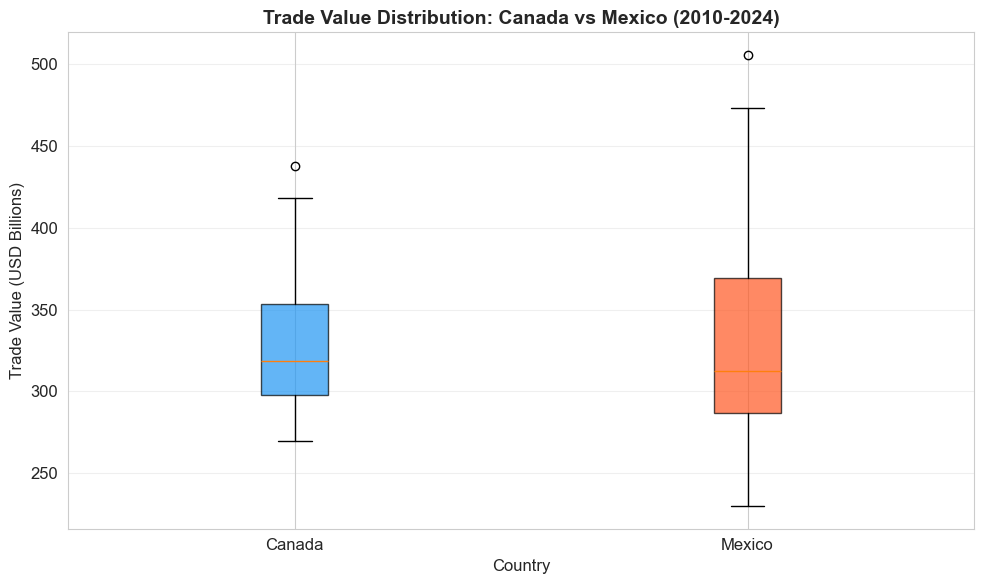

hart 6 saved!


In [11]:
# ── Chart 6: Trade Value Distribution by Country ───
fig, ax = plt.subplots(figsize=(10, 6))

trade_data = [
    df[df['country_Canada'] == True]['trade_value'].values,
    df[df['country_Mexico'] == True]['trade_value'].values
]

bp = ax.boxplot(trade_data, labels=['Canada', 'Mexico'], 
                patch_artist=True, notch=False)

bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
for box in bp['boxes']:
    box.set_alpha(0.7)

ax.set_title('Trade Value Distribution: Canada vs Mexico (2010-2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Trade Value (USD Billions)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(REPORTS + 'chart6_trade_distribution.png', dpi=150)
plt.show()
print("Chart 6 saved!")

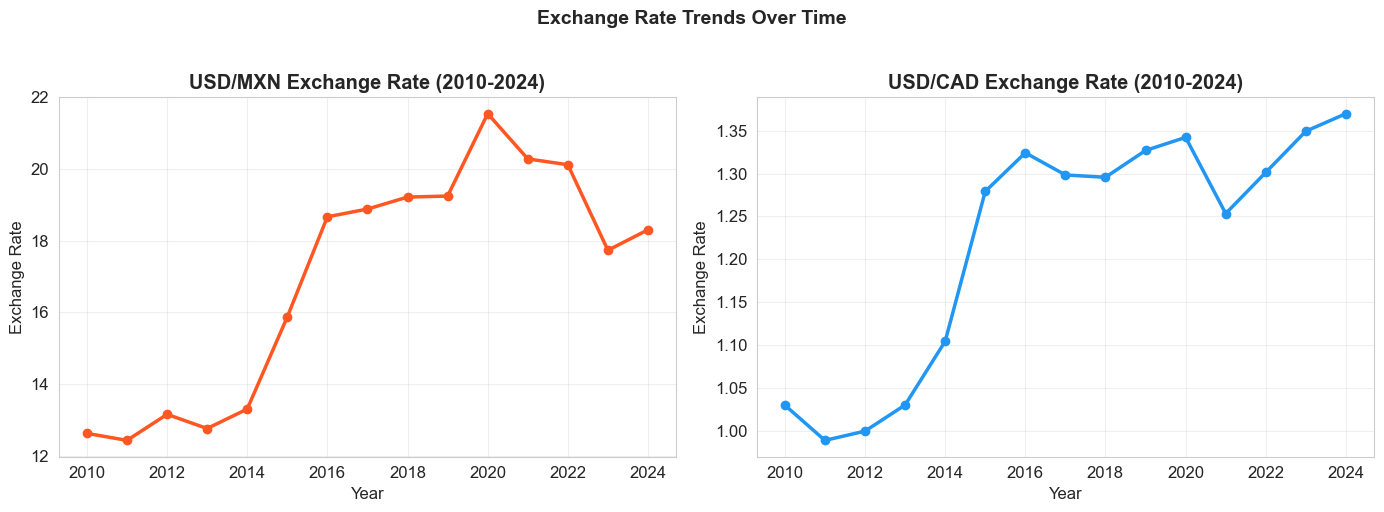

Chart 7 saved!


In [12]:
# ── Chart 7: Exchange Rates Over Time ──────────────
canada = df[df['country_Canada'] == True].sort_values('year')
mexico = df[df['country_Mexico'] == True].sort_values('year')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MXN over time
axes[0].plot(mexico['year'], mexico['exchange_rate_mxn'],
             marker='o', linewidth=2.5, color='#FF5722')
axes[0].set_title('USD/MXN Exchange Rate (2010-2024)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Exchange Rate')
axes[0].grid(True, alpha=0.3)

# CAD over time
axes[1].plot(canada['year'], canada['exchange_rate_cad'],
             marker='o', linewidth=2.5, color='#2196F3')
axes[1].set_title('USD/CAD Exchange Rate (2010-2024)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Exchange Rate')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Exchange Rate Trends Over Time',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS + 'chart7_exchange_rate_trends.png', dpi=150)
plt.show()
print("Chart 7 saved!")

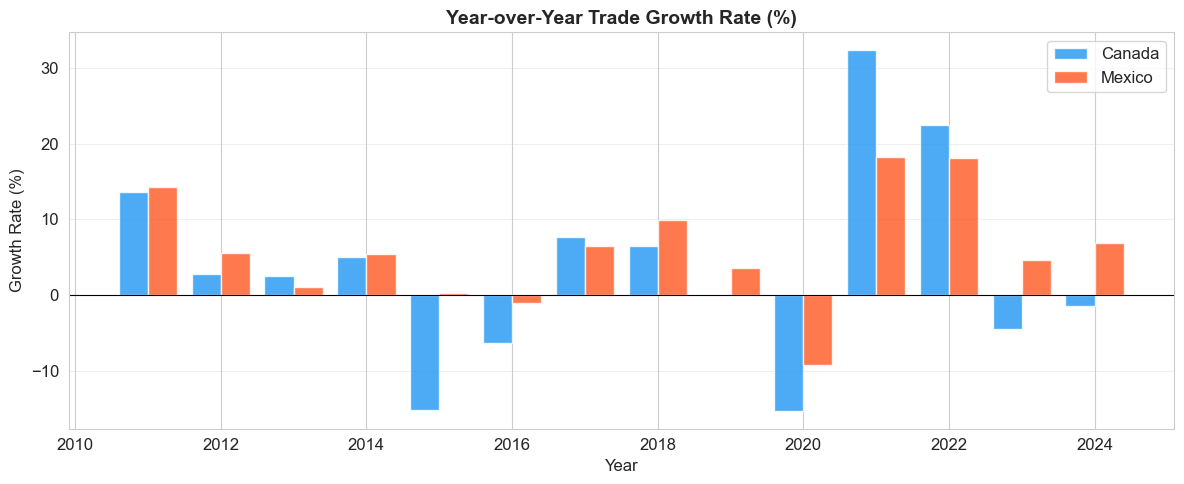

Chart 8 saved!


In [9]:
# ── Chart 8: Year over Year Trade Growth % ─────────
canada = df[df['country_Canada'] == True].sort_values('year').copy()
mexico = df[df['country_Mexico'] == True].sort_values('year').copy()

canada['growth'] = canada['trade_value'].pct_change() * 100
mexico['growth'] = mexico['trade_value'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(canada['year'] - 0.2, canada['growth'], 
       width=0.4, label='Canada', color='#2196F3', alpha=0.8)
ax.bar(mexico['year'] + 0.2, mexico['growth'], 
       width=0.4, label='Mexico', color='#FF5722', alpha=0.8)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Year-over-Year Trade Growth Rate (%)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(REPORTS + 'chart8_trade_growth.png', dpi=150)
plt.show()
print("Chart 8 saved!")

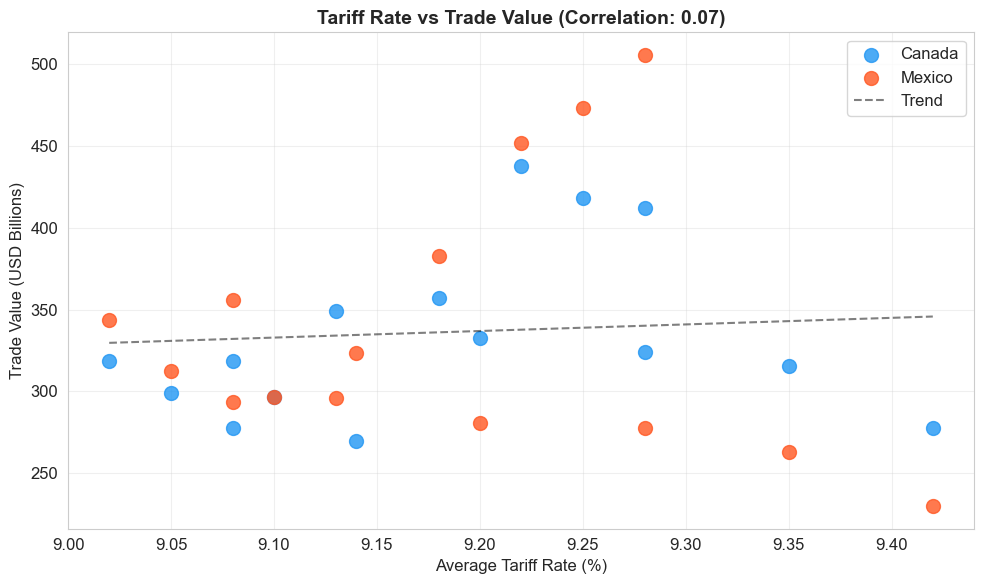

Chart 9 saved!


In [10]:
# ── Chart 9: Tariff Rate vs Trade Value ────────────
fig, ax = plt.subplots(figsize=(10, 6))

canada = df[df['country_Canada'] == True]
mexico = df[df['country_Mexico'] == True]

ax.scatter(canada['avg_tariff_rate'], canada['trade_value'],
           color='#2196F3', s=100, label='Canada', alpha=0.8)
ax.scatter(mexico['avg_tariff_rate'], mexico['trade_value'],
           color='#FF5722', s=100, label='Mexico', alpha=0.8)

# Trend line
z = np.polyfit(df['avg_tariff_rate'], df['trade_value'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['avg_tariff_rate'].min(), 
                      df['avg_tariff_rate'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, label='Trend')

ax.set_title('Tariff Rate vs Trade Value (Correlation: 0.07)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Tariff Rate (%)')
ax.set_ylabel('Trade Value (USD Billions)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS + 'chart9_tariff_vs_trade.png', dpi=150)
plt.show()
print("Chart 9 saved!")